Similar to attractors.ipynb, except here, the external input is always on. 

#### get packages

In [1]:
import numpy as np
import pandas as pd
import torch
from connectome_interpreter import *
from nglscenes import *
import scipy as sp
from tqdm import tqdm
import plotly.express as px
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
import re
import umap

import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from typing import Iterable, Union, Optional, Callable

c:\Users\44745\miniconda3\envs\coin\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


#### get data & stimuli

In [ ]:
inprop = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_inprop_all_neuron.npz")
syncount = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_syncount_all_neuron.npz")
# axo-dendritic
ad_inprop = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_ad_inprop_all_neuron.npz")
ad_syncount = sp.sparse.load_npz(
    "../data/fafb_all_neuron/fafb_ad_syncount_all_neuron.npz"
)

meta = pd.read_csv("../data/fafb_all_neuron/fafb_all_neuron_meta.csv", index_col=0)
meta["type_side"] = meta.cell_type + "_" + meta.side

idx_to_type = dict(zip(meta.idx, meta.cell_type))
idx_to_sign = dict(zip(meta.idx, meta.sign))

C:\Users\44745\AppData\Local\Temp\ipykernel_31764\2459288910.py:9: DtypeWarning: Columns (0: hartenstein_hemilineage, 1: idx) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv("data/fafb_all_neuron/fafb_all_neuron_meta.csv", index_col=0)


In [3]:
meta.loc[meta.cell_type.str.contains('ORN'), ["glomerulus"]] = meta.loc[
    meta.cell_type.str.contains("ORN"), "cell_type"
].str.replace("ORN_", "")

idx_to_glomeruli = dict(zip(meta.idx, meta.glomerulus))
add_types = [
    "LgAG1",
    "LB1a",
    "LB1b",
    "LB1c",
    "LB1d",
    "LC6",
    "LB3",
]
idx_to_glomeruli.update(dict(zip(meta.idx[meta.cell_type.isin(add_types)], 
    meta.cell_type[meta.cell_type.isin(add_types)])))
type_to_glomerulus = dict(zip(meta.cell_type, meta.glomerulus))

In [4]:
# 10^-2 (when they did experiments), Ca imaging
# contains Hallem
door = load_dataset('DoOR_adult')
door.columns = [col.split("_")[0] for col in door.columns]

In [5]:
add_response = pd.DataFrame(
    index=add_types, columns=["labellar_bitter", "visual_loom", "leg_bitter"]
).fillna(0)

add_response.loc[["LC6"], "visual_loom"] = 1
# only runs for FAFB after taking GRN info from Tastekin et al. 2025
add_response.loc[["LgAG1"], "leg_bitter"] = 1
add_response.loc[["LB1a", "LB1b", "LB1c", "LB1d"], "labellar_bitter"] = 1

# combine with door
door = door.add(add_response, fill_value=0).fillna(0)

## modelling

In [6]:
inprop_signed = add_sign(inprop, idx_to_sign)
ad_inprop_signed = add_sign(ad_inprop, idx_to_sign)

In [7]:
# input definition
num_layers = 800

selected_odours = {
    "ethanol",
    "3-octanol",
    "geosmin",
    "benzaldehyde",
    "4-methylcyclohexanol",
    # "apple cider vinegar (1%)",
    # "leg_sugar",
    "leg_bitter",
    "labellar_bitter",
    "visual_loom",
    "11-cis vaccenyl acetate",
}
sensory_indices = sorted(list(set(meta.idx[meta.cell_type.str.contains('ORN')
                                           | meta.cell_type.isin(add_types)])))  # all ORN

ms = []
odours = list(set(door.columns).intersection(selected_odours))
for odour in odours:
    glom2act = dict(door.loc[:, door.columns == odour].reset_index().values)
    v = np.array(
        [
            glom2act[idx_to_glomeruli[idx]] if idx_to_glomeruli[idx] in glom2act else 0
            for idx in sensory_indices
        ]
    )
    m = np.zeros((len(sensory_indices), num_layers), dtype=np.float32)
    # put v in all columns of m
    m[:, 0:num_layers] = v[:, np.newaxis]
    # m[:, 640:700] = v[:, np.newaxis]

    # m[:, 0] = v
    ms.append(m)

d_in = np.stack(ms)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
allacts_initial = []

for slope in tqdm(range(1, 6)): 
    # for slope in [3]:
    for tau in [1, 5, 10, 20]:
        # for tau in [12, 15, 20, 25]:
        model = MultilayeredNetwork(
            inprop_signed,
            sensory_indices,
            threshold=0,
            tanh_steepness=slope,
            num_layers=num_layers,
            tau=tau,
            # default_bias = 0.01,
            idx_to_group=idx_to_type,
            device=device
        )
        out = model(d_in)

        acts = get_neuron_activation(
            out[:,:,:num_layers],
            meta.idx[
                # cell type isn't entirely digit 
                ~meta.cell_type.str.isdigit()
                # meta.cell_type.isin(fbtan_types)
                # meta.cell_type.str.contains('KC') |
                # meta.cell_type.isin(['APL'])
            ],
            odours,
            idx_to_type,
        )
        acts["group"] = acts["group"].str.split("_").str[0]
        acts = acts.groupby(["group", "batch_name"]).mean().reset_index()

        # reshape
        acts_long = acts.melt(
            id_vars=["group", "batch_name"],
            value_vars=[col for col in acts.columns if col.startswith("time_")],
            var_name="time_point",
            value_name="activation",
        )
        acts_long['time_point'] = acts_long['time_point'].str.replace('time_','').astype(int)
        acts_wide = acts_long.pivot(
            index=["batch_name", "time_point"],
            columns="group",
            values="activation",
        ).reset_index()
        acts_wide['tau'] = tau 
        acts_wide['slope'] = slope
        allacts_initial.append(acts_wide)

allacts_initial = pd.concat(allacts_initial, ignore_index=True)

100%|██████████| 5/5 [31:31<00:00, 378.33s/it]


# across taus 
The effect of tau (for the same slope) on steady state is already investigated above. Here we look at the effect of tau on immediate response. 

In [9]:
id_cols = ["batch_name", "tau", "slope"]  # time_point gets aggregated out
group_cols = [c for c in allacts_initial.columns if c not in id_cols + ["time_point"]]

agg = allacts_initial.groupby(id_cols)[group_cols].agg(["mean", "max"])
agg.columns = agg.columns.set_names(["group", "stat"])

allacts_initial_reshape = (
    agg.stack(level="group", future_stack=True)
    .reset_index()
    .rename(columns={"mean": "act_mean", "max": "act_max"})
)

In [16]:
allacts_initial_reshape["tau_str"] = "tau_" + allacts_initial_reshape.tau.astype(str)
allacts_initial_reshape["slope_str"] = "slope_" + allacts_initial_reshape.slope.astype(
    str
)
initial_act_max = allacts_initial_reshape.pivot_table(
    index=["group", "batch_name", "slope_str", 'slope'], columns="tau_str", values="act_max"
).reset_index()

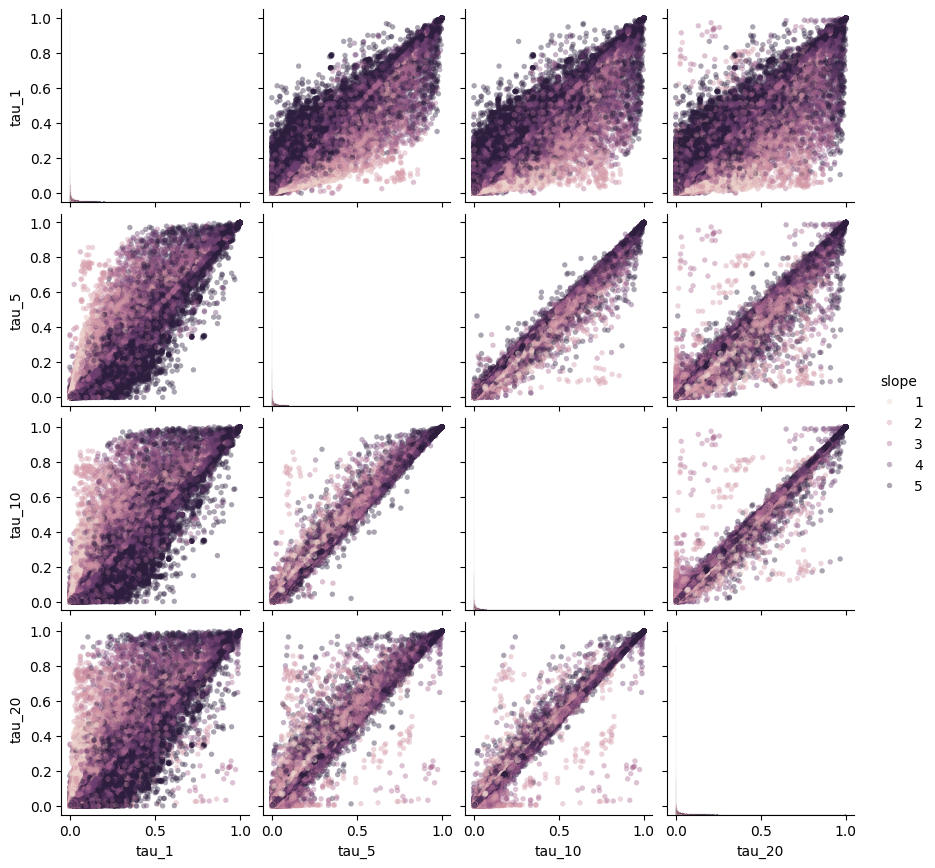

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

tau_cols = sorted(
    [col for col in initial_act_max.columns if col.startswith("tau_")],
    key=lambda c: float(c.split("_")[1]),
)

# df = initial_act_max[initial_act_max.slope_str == "slope_3"]

g = sns.pairplot(
    initial_act_max,
    vars=tau_cols,
    hue="slope",
    diag_kind="hist",
    plot_kws=dict(s=15, alpha=0.4, linewidth=0),
    height=2.2,
)

g.figure.savefig("taus.pdf", bbox_inches="tight")
plt.show()

In [20]:
myslope = 3
mytau = 20
model = MultilayeredNetwork(
            inprop_signed,
            sensory_indices,
            threshold=0,
            tanh_steepness=myslope,
            num_layers=num_layers,
            tau=mytau,
            # default_bias = 0.01,
            idx_to_group=idx_to_type,
            device=device
        )
out = model(d_in)

acts = get_neuron_activation(
    out,
    meta.idx[
        meta.cell_type.isin(
            initial_act_max.group[
                (initial_act_max.slope_str == "slope_3")
                & (
                    initial_act_max.batch_name.isin(
                        ["leg_bitter", "labellar_bitter", "visual_loom"]
                    )
                )
                & (initial_act_max.tau_1 > 0.9)
                & (initial_act_max.tau_20 < 0.2)
            ]
        )
    ],
    odours,
    idx_to_type,
)
plot_timeseries(acts)